In [18]:
import pandas as pd

In [ ]:
full_table = pd.read_parquet("../data/processed/fuel_clean.parquet")
full_table.head()

,ServiceStationName,Address,Suburb,Postcode,Brand,FuelCode,PriceUpdatedDate,Price,source_file,state,brand_group,fuel_name
0,Ampol Denham Court,"194 CAMPBELLTOWN RD, DENHAM COURT NSW 2565",DENHAM COURT,2565,Ampol,U91,2026-04-01 00:06:24,239.5,fuelcheck_pricehistory_apr2026.xlsx,NSW,Ampol,Unleaded 91
1,Liberty Albert,"9, Melrose Road, Albert NSW 2873",Albert,2873,Liberty,U91,2026-04-01 00:22:59,274.9,fuelcheck_pricehistory_apr2026.xlsx,NSW,Liberty,Unleaded 91
2,Liberty Bourke,"96-104 ANSON ST, BOURKE NSW 2840",BOURKE,2840,Liberty,U91,2026-04-01 00:23:27,264.9,fuelcheck_pricehistory_apr2026.xlsx,NSW,Liberty,Unleaded 91
3,Liberty Bourke,"96-104 ANSON ST, BOURKE NSW 2840",BOURKE,2840,Liberty,P95,2026-04-01 00:23:27,274.9,fuelcheck_pricehistory_apr2026.xlsx,NSW,Liberty,Premium Unleaded Petrol 95
4,SHELL TAMWORTH TRUCKSTOP (unmanned),"9-13 Gunnedah Road, Tamworth NSW 2340",Tamworth,2340,Shell,DL,2026-04-01 00:23:53,299.9,fuelcheck_pricehistory_apr2026.xlsx,NSW,Shell,Diesel


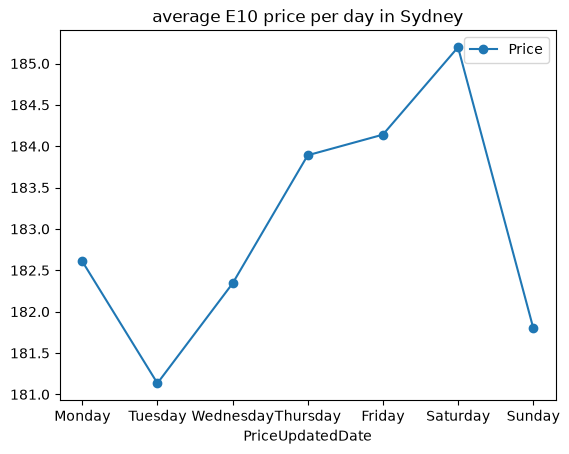

In [38]:
# which day is cheapest
days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
full_table["Postcode"] = full_table["Postcode"].astype("int16")

sydney_oil = full_table.loc[(
                            (full_table["Postcode"].between(2000, 2234)) | 
                            (full_table["Postcode"].between(2555, 2574)) | 
                            (full_table["Postcode"].between(2740, 2786))
                           )]

(sydney_oil.loc[sydney_oil["FuelCode"] == "E10"]
    .groupby(sydney_oil["PriceUpdatedDate"].dt.day_name())
    .agg({"Price":"mean"})
    .reindex(days)
).plot(title="average E10 price per day in Sydney",
       marker="o");

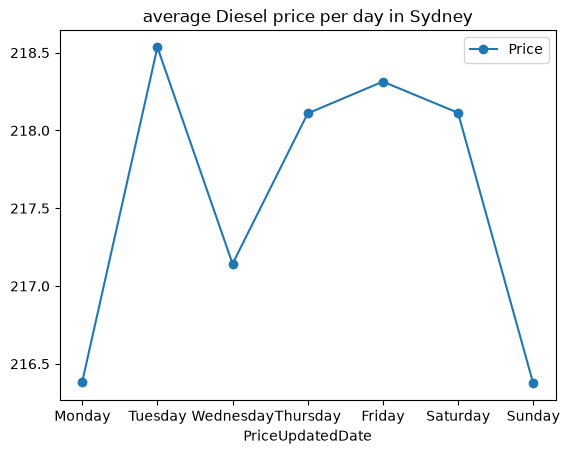

In [40]:
(sydney_oil.loc[sydney_oil["FuelCode"] == "DL"]
    .groupby(sydney_oil["PriceUpdatedDate"].sort_values().dt.day_name())
    .agg({"Price":"mean"})
    .reindex(days)
).plot(title="average Diesel price per day in Sydney",
       marker="o");

- The cheapest days for E10 are Tuesday and Sunday and the  most expensive day is Saturday
- The cheapest days for Diesel are Monday and Sunday and the most expensive day is Tuesday
- For vans and trucks, the most economically efficient day for buying fuel is Sunday